<a href="https://colab.research.google.com/github/ac-navalta/data-mining/blob/main/Phase_2_Data_Cleaning_and_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
# Load dataset
csv_file_path = 'https://raw.githubusercontent.com/ac-navalta/data-mining/main/Philippine_Earthquakes_USGS.csv'

df = pd.read_csv(csv_file_path)
display(df.head())

,id,mag,place,time,updated,tz,url,detail,felt,cdi,...,nst,dmin,rms,gap,magType,type_property,title,longitude,latitude,depth
0,us7000rs17,4.4,"35 km W of Sangay, Philippines",2026-01-26 08:33:44.474,2026-01-26 12:30:30.040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,...,25.0,1.947,0.66,136.0,mb,earthquake,"M 4.4 - 35 km W of Sangay, Philippines",123.7249,6.4342,14.819
1,us7000rrsh,4.9,"38 km S of Sarangani, Philippines",2026-01-24 18:45:54.402,2026-01-24 19:01:10.040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,...,63.0,2.002,0.92,77.0,mb,earthquake,"M 4.9 - 38 km S of Sarangani, Philippines",125.4189,5.0607,180.096
2,us7000rrqv,4.3,"8 km E of Marihatag, Philippines",2026-01-24 08:26:02.342,2026-01-24 11:32:51.040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,...,40.0,1.896,0.80,107.0,mb,earthquake,"M 4.3 - 8 km E of Marihatag, Philippines",126.3705,8.8077,75.390
3,us7000rrqm,4.5,"7 km NE of Sarangani, Philippines",2026-01-24 07:30:17.101,2026-01-24 07:53:25.040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,...,40.0,1.604,0.94,86.0,mb,earthquake,"M 4.5 - 7 km NE of Sarangani, Philippines",125.5072,5.4571,199.646
4,us7000rr3q,4.7,"7 km NW of Bantogon, Philippines",2026-01-21 20:59:22.170,2026-01-22 17:34:20.040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,...,45.0,12.425,0.65,87.0,mb,earthquake,"M 4.7 - 7 km NW of Bantogon, Philippines",123.9820,6.5810,9.895


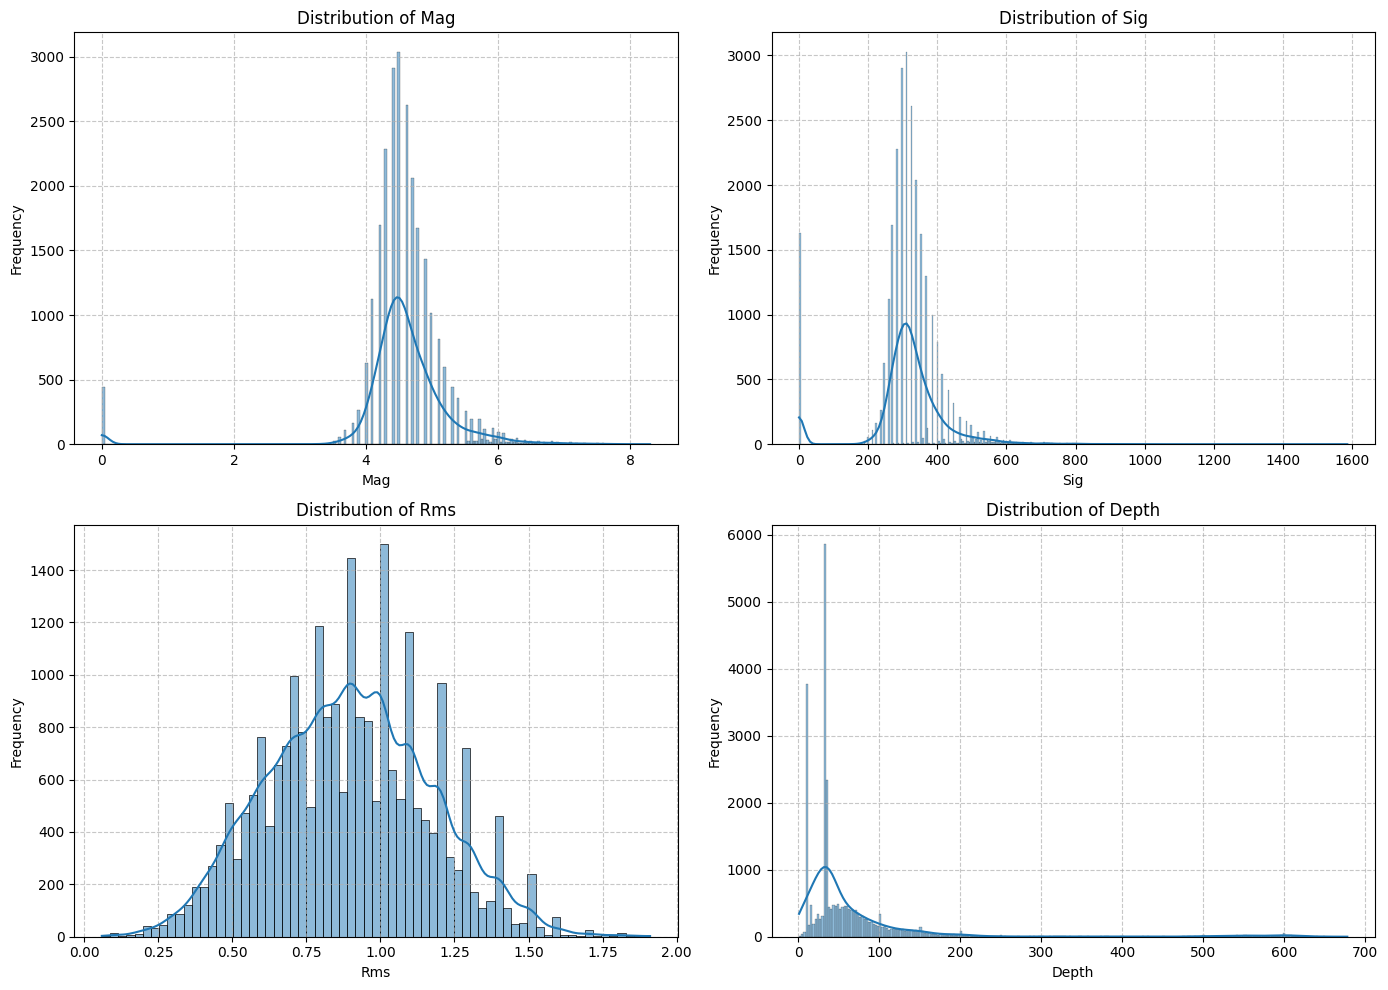

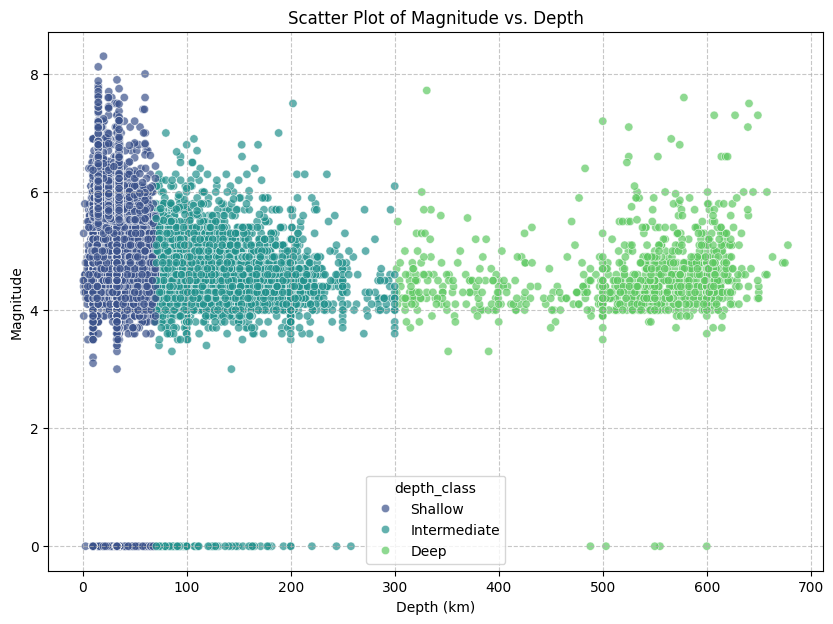

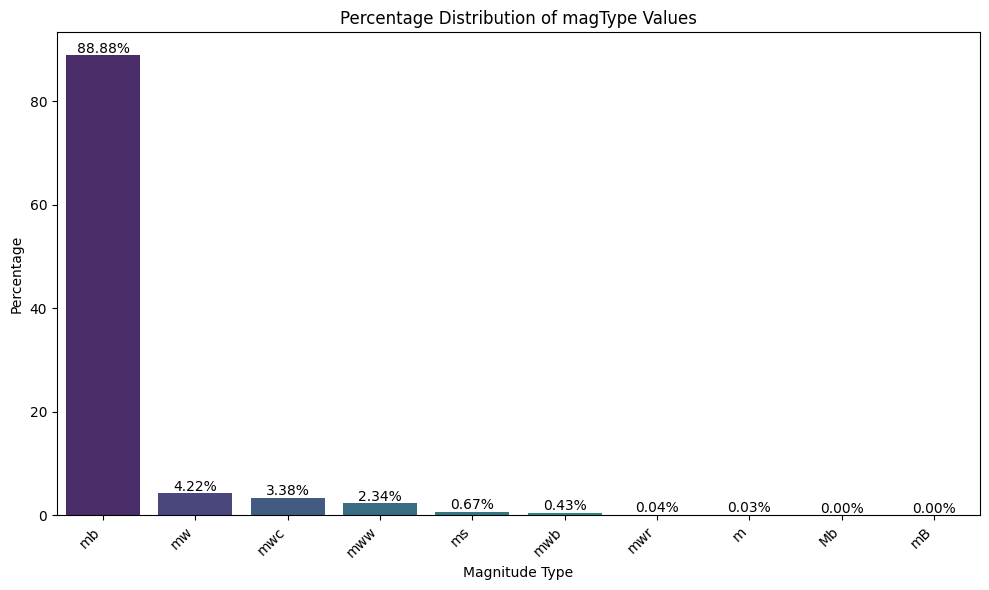

In [14]:
# Exploratory Data Analysis

columns_to_plot = ['mag', 'sig', 'rms', 'depth']

# Histograms and distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(columns_to_plot):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col.capitalize()}')
    axes[i].set_xlabel(col.capitalize())
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Create the 'depth_class' column
def depth_class(d):
    if d <= 70:
        return "Shallow"
    elif d <= 300:
        return "Intermediate"
    else:
        return "Deep"

df["depth_class"] = df["depth"].apply(depth_class)

# Scatter plot: mag vs depth
plt.figure(figsize=(10, 7))
sns.scatterplot(x='depth', y='mag', data=df, hue='depth_class', palette='viridis', alpha=0.7)
plt.title('Scatter Plot of Magnitude vs. Depth')
plt.xlabel('Depth (km)')
plt.ylabel('Magnitude')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# magTypes
magtype_counts = df['magType'].value_counts()
percentage_magtype = (magtype_counts / magtype_counts.sum()) * 100

plt.figure(figsize=(10, 6))
sns.barplot(x=percentage_magtype.index, y=percentage_magtype.values, hue=percentage_magtype.index, palette='viridis', legend=False)
plt.title('Percentage Distribution of magType Values')
plt.xlabel('Magnitude Type')
plt.ylabel('Percentage')
plt.xticks(rotation=45, ha='right')
for index, value in enumerate(percentage_magtype.values):
    plt.text(index, value + 0.5, f'{value:.2f}%', ha='center')
plt.tight_layout()
plt.show()

In [15]:
# Missing Values

missing_values = df.isnull().sum()
print(missing_values)

id                   0
mag               1186
place                0
time                 0
updated              0
tz               26686
url                  0
detail               0
felt             24614
cdi              24614
mmi              25547
alert            26351
status               0
tsunami              0
sig                  0
net                  0
code                 0
ids                  0
sources              0
types                0
nst              15628
dmin             17604
rms               2552
gap              11476
magType           1631
type_property        0
title                0
longitude            0
latitude             0
depth                2
depth_class          0
dtype: int64


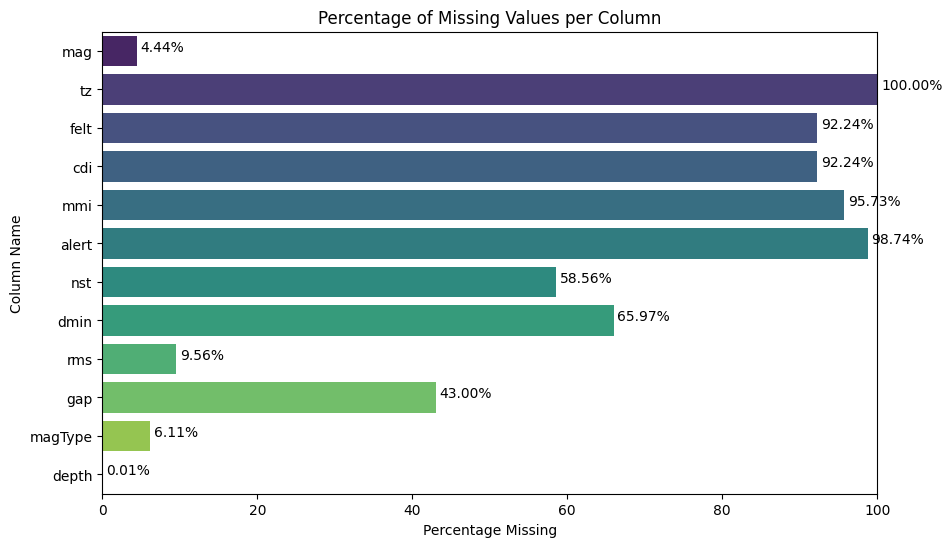

In [16]:
# Filter out columns with no missing values
missing_values_exist = missing_values[missing_values > 0]

# Calculate the percentage of missing values
total_rows = len(df)
percentage_missing = (missing_values_exist / total_rows) * 100

# Create a DataFrame for plotting
percentage_missing_df = percentage_missing.reset_index()
percentage_missing_df.columns = ['Column', 'Percentage_Missing']

# Visualize the percentage of missing values
plt.figure(figsize=(10, 6))
sns.barplot(x='Percentage_Missing', y='Column', hue='Column', data=percentage_missing_df, palette='viridis', legend=False)
plt.title('Percentage of Missing Values per Column')
plt.xlabel('Percentage Missing')
plt.ylabel('Column Name')
plt.xlim(0, 100) # Ensure x-axis goes from 0 to 100%
for index, row in percentage_missing_df.iterrows():
    plt.text(row['Percentage_Missing'] + 0.5, index, f"{row['Percentage_Missing']:.2f}%")
plt.show()

In [17]:
# Data Cleaning
df = df.drop(columns=["tz", "felt", "cdi", "mmi", "alert", "nst", "dmin", "gap"])

# remove: rows with blank magnitude
df = df.dropna(subset=["mag"])

# remove: rows with 0.0 magnitude
df = df[df["mag"] != 0.0]

# remove: rows whose magType is not 'mb'
df = df[df["magType"] == "mb"]

# fill: rms (median)
df["rms"] = df["rms"].fillna(df["rms"].median())

# fill: depth (median)
df["depth"] = df["depth"].fillna(df["depth"].median())

# optional: reset index after filtering
df = df.reset_index(drop=True)

df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22270 entries, 0 to 22269
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             22270 non-null  object 
 1   mag            22270 non-null  float64
 2   place          22270 non-null  object 
 3   time           22270 non-null  object 
 4   updated        22270 non-null  object 
 5   url            22270 non-null  object 
 6   detail         22270 non-null  object 
 7   status         22270 non-null  object 
 8   tsunami        22270 non-null  int64  
 9   sig            22270 non-null  int64  
 10  net            22270 non-null  object 
 11  code           22270 non-null  object 
 12  ids            22270 non-null  object 
 13  sources        22270 non-null  object 
 14  types          22270 non-null  object 
 15  rms            22270 non-null  float64
 16  magType        22270 non-null  object 
 17  type_property  22270 non-null  object 
 18  title 

,0
id,0
mag,0
place,0
time,0
updated,0
url,0
detail,0
status,0
tsunami,0
sig,0


In [18]:
# Data Transformation

# Normalize: depth, sig, rms; use Z-score standardization
# Normalize: longitude, latitude; use min-max scaling
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# ---- Z-score standardization (create new columns) ----
z_cols = ["depth", "sig", "rms"]

z_scaler = StandardScaler()
df[['depth_z', 'sig_z', 'rms_z']] = z_scaler.fit_transform(df[z_cols])

# ---- Min-max scaling (0 to 1) for new columns ----
mm_cols = ["longitude", "latitude"]

mm_scaler = MinMaxScaler()
df['longitude_mm'] = mm_scaler.fit_transform(df[['longitude']])
df['latitude_mm'] = mm_scaler.fit_transform(df[['latitude']])

df[['depth', 'depth_z', 'sig', 'sig_z', 'rms', 'rms_z', 'longitude', 'longitude_mm', 'latitude', 'latitude_mm']]

,depth,depth_z,sig,sig_z,rms,rms_z,longitude,longitude_mm,latitude,latitude_mm
0,14.819,-0.567680,298,-0.426689,0.66,-0.840484,123.7249,0.358378,6.4342,0.177207
1,180.096,1.038734,369,1.064741,0.92,0.146322,125.4189,0.451164,5.0607,0.116132
2,75.390,0.021042,284,-0.720774,0.80,-0.309127,126.3705,0.503286,8.8077,0.282747
3,199.646,1.228751,312,-0.132604,0.94,0.222230,125.5072,0.456000,5.4571,0.133759
4,9.895,-0.615539,340,0.455565,0.65,-0.878438,123.9820,0.372460,6.5810,0.183734
...,...,...,...,...,...,...,...,...,...,...
22265,77.000,0.036690,354,0.749650,0.88,-0.005495,119.9680,0.152599,17.2790,0.659434
22266,90.000,0.163044,354,0.749650,0.88,-0.005495,127.3130,0.554910,5.8720,0.152208
22267,67.000,-0.060505,312,-0.132604,0.88,-0.005495,120.1580,0.163006,14.9940,0.557828
22268,139.000,0.639301,354,0.749650,0.88,-0.005495,120.8320,0.199923,13.4660,0.489884


In [19]:
#Feature Engineering

# Depth, Depth Class, and Deepth encoded
def depth_class(d):
    if d <= 70:
        return "Shallow"
    elif d <= 300:
        return "Intermediate"
    else:
        return "Deep"

df["depth_class"] = df["depth"].apply(depth_class)

depth_map = {
    "Deep": 0,
    "Intermediate": 1,
    "Shallow": 2
}

df["depth_encoded"] = df["depth_class"].map(depth_map)

# Magnitude, Magnitude Class, and Magnitude encoded
def mag_class(m):
    if m <= 3:
        return "Micro"
    elif m < 4:
        return "Minor"
    elif m < 5:
        return "Light"
    elif m < 6:
        return "Moderate"
    elif m < 7:
        return "Strong"
    elif m < 8:
        return "Major"
    else:
        return "Great"

df["mag_class"] = df["mag"].apply(mag_class)

mag_map = {
    "Micro": 0,
    "Minor": 1,
    "Light": 2,
    "Moderate": 3,
    "Strong": 4,
    "Major": 5,
    "Great": 6
}

df["mag_encoded"] = df["mag_class"].map(mag_map)

# Risk Levels, and Risk Levels encoded
def assign_risk(row):
    mag = row["mag_class"]
    depth = row["depth_class"]

    if mag in ['Micro', 'Minor']:
        return "Low"

    if mag == 'Light':
        return "Moderate" if depth == "Shallow" else "Low"

    if mag == 'Moderate':
        if depth == "Shallow":
            return "High"
        elif depth == "Intermediate":
            return "Moderate"
        return "Low"

    if mag == 'Strong':
        if depth == "Shallow":
            return "Very High"
        elif depth == "Intermediate":
            return "High"
        return "Moderate"

    if mag == 'Major':
        return "Very High" if depth != "Deep" else "High"

    if mag == 'Great':
        return "Very High"

df['risk_level'] = df.apply(assign_risk, axis=1)

risk_map = {
    "Low": 0,
    "Moderate": 1,
    "High": 2,
    "Very High": 3
}

df['risk_encoded'] = df['risk_level'].map(risk_map)

In [20]:
df

,id,mag,place,time,updated,url,detail,status,tsunami,sig,...,depth_z,sig_z,rms_z,longitude_mm,latitude_mm,depth_encoded,mag_class,mag_encoded,risk_level,risk_encoded
0,us7000rs17,4.4,"35 km W of Sangay, Philippines",2026-01-26 08:33:44.474,2026-01-26 12:30:30.040,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,reviewed,0,298,...,-0.567680,-0.426689,-0.840484,0.358378,0.177207,2,Light,2,Moderate,1
1,us7000rrsh,4.9,"38 km S of Sarangani, Philippines",2026-01-24 18:45:54.402,2026-01-24 19:01:10.040,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,reviewed,0,369,...,1.038734,1.064741,0.146322,0.451164,0.116132,1,Light,2,Low,0
2,us7000rrqv,4.3,"8 km E of Marihatag, Philippines",2026-01-24 08:26:02.342,2026-01-24 11:32:51.040,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,reviewed,0,284,...,0.021042,-0.720774,-0.309127,0.503286,0.282747,1,Light,2,Low,0
3,us7000rrqm,4.5,"7 km NE of Sarangani, Philippines",2026-01-24 07:30:17.101,2026-01-24 07:53:25.040,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,reviewed,0,312,...,1.228751,-0.132604,0.222230,0.456000,0.133759,1,Light,2,Low,0
4,us7000rr3q,4.7,"7 km NW of Bantogon, Philippines",2026-01-21 20:59:22.170,2026-01-22 17:34:20.040,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,reviewed,0,340,...,-0.615539,0.455565,-0.878438,0.372460,0.183734,2,Light,2,Moderate,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22265,usp000002a,4.8,"48 km W of Darapidap, Philippines",1973-01-07 20:42:11.100,2014-11-07 07:21:07.422,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,reviewed,0,354,...,0.036690,0.749650,-0.005495,0.152599,0.659434,1,Light,2,Low,0
22266,usp000001b,4.8,"136 km ESE of Pondaguitan, Philippines",1973-01-05 18:07:46.200,2014-11-07 07:21:07.324,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,reviewed,0,354,...,0.163044,0.749650,-0.005495,0.554910,0.152208,1,Light,2,Low,0
22267,usp0000012,4.5,"2 km N of San Marcelino, Philippines",1973-01-04 20:23:45.800,2014-11-07 07:21:07.297,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,reviewed,0,312,...,-0.060505,-0.132604,-0.005495,0.163006,0.557828,2,Light,2,Moderate,1
22268,usp000000n,4.8,"1 km SE of Odala, Philippines",1973-01-03 12:10:04.500,2014-11-07 07:21:07.249,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,reviewed,0,354,...,0.639301,0.749650,-0.005495,0.199923,0.489884,1,Light,2,Low,0


In [21]:
#Feature Selection

df = df.drop(columns=['id', 'place', 'time', 'updated', 'url', 'detail', 'status', 'net', 'code', 'ids', 'sources', 'types', 'title', 'type_property', 'magType', 'rms'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22270 entries, 0 to 22269
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   mag            22270 non-null  float64
 1   tsunami        22270 non-null  int64  
 2   sig            22270 non-null  int64  
 3   longitude      22270 non-null  float64
 4   latitude       22270 non-null  float64
 5   depth          22270 non-null  float64
 6   depth_class    22270 non-null  object 
 7   depth_z        22270 non-null  float64
 8   sig_z          22270 non-null  float64
 9   rms_z          22270 non-null  float64
 10  longitude_mm   22270 non-null  float64
 11  latitude_mm    22270 non-null  float64
 12  depth_encoded  22270 non-null  int64  
 13  mag_class      22270 non-null  object 
 14  mag_encoded    22270 non-null  int64  
 15  risk_level     22270 non-null  object 
 16  risk_encoded   22270 non-null  int64  
dtypes: float64(9), int64(5), object(3)
memory usage: 2

In [22]:
output_csv_path = '/content/drive/MyDrive/CC19/philippine_earthquakes_processed.csv'
df.to_csv(output_csv_path, index=False)
print(f"DataFrame successfully exported to '{output_csv_path}'")

DataFrame successfully exported to '/content/drive/MyDrive/CC19/philippine_earthquakes_processed.csv'
